1.Generate dataset


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Seeding for reproducibility
np.random.seed(42)

# Generating synthetic data
dates = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
categories = ['Electronics', 'Home', 'Clothing', 'Books']
regions = ['North', 'South', 'East', 'West']

data = {
    'OrderID': np.arange(1001, 1367),
    'Date': np.random.choice(dates, 366),
    'Category': np.random.choice(categories, 366),
    'Region': np.random.choice(regions, 366),
    'Price': np.random.uniform(10, 500, 366).round(2),
    'Quantity': np.random.randint(1, 10, 366),
    'Discount': np.random.choice([0, 0.05, 0.1, 0.2], 366, p=[0.6, 0.2, 0.1, 0.1])
}

# Introduce some null values for cleaning practice
data['Region'].flat[np.random.choice(366, 10, replace=False)] = np.nan
data['Price'].flat[np.random.choice(366, 5, replace=False)] = np.nan

df = pd.DataFrame(data)

# Display first few rows
print("Dataset Created Successfully!")
print(df.head())

Dataset Created Successfully!
   OrderID       Date     Category Region   Price  Quantity  Discount
0     1001 2023-04-13     Clothing  North  133.69         1      0.00
1     1002 2023-12-15         Home  North  359.54         1      0.00
2     1003 2023-09-28         Home   West  448.65         9      0.00
3     1004 2023-04-17         Home   West  260.72         7      0.10
4     1005 2023-03-13  Electronics  South  270.74         1      0.05


Part 1

In [9]:
#Inspection
# Checking datatypes of all columns 
print("Dataset Info:")
print(df.info())
#Check how many mising values in Region and Price
print("Missing values in Region:",df["Region"].isna().sum())
print("Missing values in Price:",df["Price"].isna().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   OrderID   366 non-null    int64         
 1   Date      366 non-null    datetime64[ns]
 2   Category  366 non-null    object        
 3   Region    366 non-null    object        
 4   Price     361 non-null    float64       
 5   Quantity  366 non-null    int32         
 6   Discount  366 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(2)
memory usage: 18.7+ KB
None
Missing values in Region: 0
Missing values in Price: 5


In [12]:
#Replace missing values in Region
df["Region"]=df["Region"].fillna("Unknown")
#Drop rows with prices
df=df.dropna(subset=["Price"])

print("Missing values count")
print(df.isna().sum())



Missing values count
OrderID     0
Date        0
Category    0
Region      0
Price       0
Quantity    0
Discount    0
dtype: int64


In [13]:
#Feature Engineering
#Total_Sales=Price X Quantity x (1-Discount)
df["Total_Sales"]=df["Price"]*df["Quantity"]*(1-df["Discount"])


Part 2 Aggregation and Analysis


In [30]:
#Category wise total sales
category_wise_sales=df.groupby("Category").agg({'Total_Sales':'sum'})
maxsales_category=category_wise_sales.sort_values("Total_Sales",ascending=False).head(1).index[0]
print("Category wise sales:")
print(category_wise_sales)

print("Maximum Sales Category")
print(maxsales_category)


Category wise sales:
             Total_Sales
Category                
Books        114920.7930
Clothing      92239.5075
Electronics  131085.4865
Home          97770.2250
Maximum Sales Category
Electronics


In [ ]:
#Average,median of Price
average_price=np.average(df["Price"])
median_price=np.median(df["Price"])

#Standard Deviation of Quantity sold
std_quantity=np.std(df["Quantity"])

print("Average Price:",average_price)
print("Median Price:",median_price)
print("Standard Deviation Quantity: ",std_quantity)



Average Price: 244.31858725761776
Median Price: 241.07
Standard Deviation Quantity:  2.67


In [29]:
#Find all the orders where the order includes:
#Order is from North Region
#Quantity is greater than 5
#Order should have no discount

#filtered_orders=df.query('Region=="North" & Quantity>5 & Discount==0')
filtered_orders=df[((df["Region"]=="North")&(df["Quantity"]>5)&(df["Discount"]==0))]
filtered_orders.sample(10)

,OrderID,Date,Category,Region,Price,Quantity,Discount,Total_Sales
168,1169,2023-10-13,Home,North,286.92,8,0.0,2295.36
115,1116,2023-02-17,Home,North,123.78,7,0.0,866.46
190,1191,2023-11-11,Clothing,North,174.25,8,0.0,1394.00
185,1186,2023-08-13,Home,North,436.25,7,0.0,3053.75
37,1038,2023-12-30,Clothing,North,130.52,7,0.0,913.64
34,1035,2023-07-09,Books,North,126.24,7,0.0,883.68
312,1313,2023-12-31,Books,North,281.55,6,0.0,1689.30
218,1219,2023-06-09,Clothing,North,498.47,7,0.0,3489.29
274,1275,2023-07-27,Electronics,North,295.69,9,0.0,2661.21
258,1259,2023-09-09,Home,North,126.71,8,0.0,1013.68


Part 3:Advanced Trends and Visualization

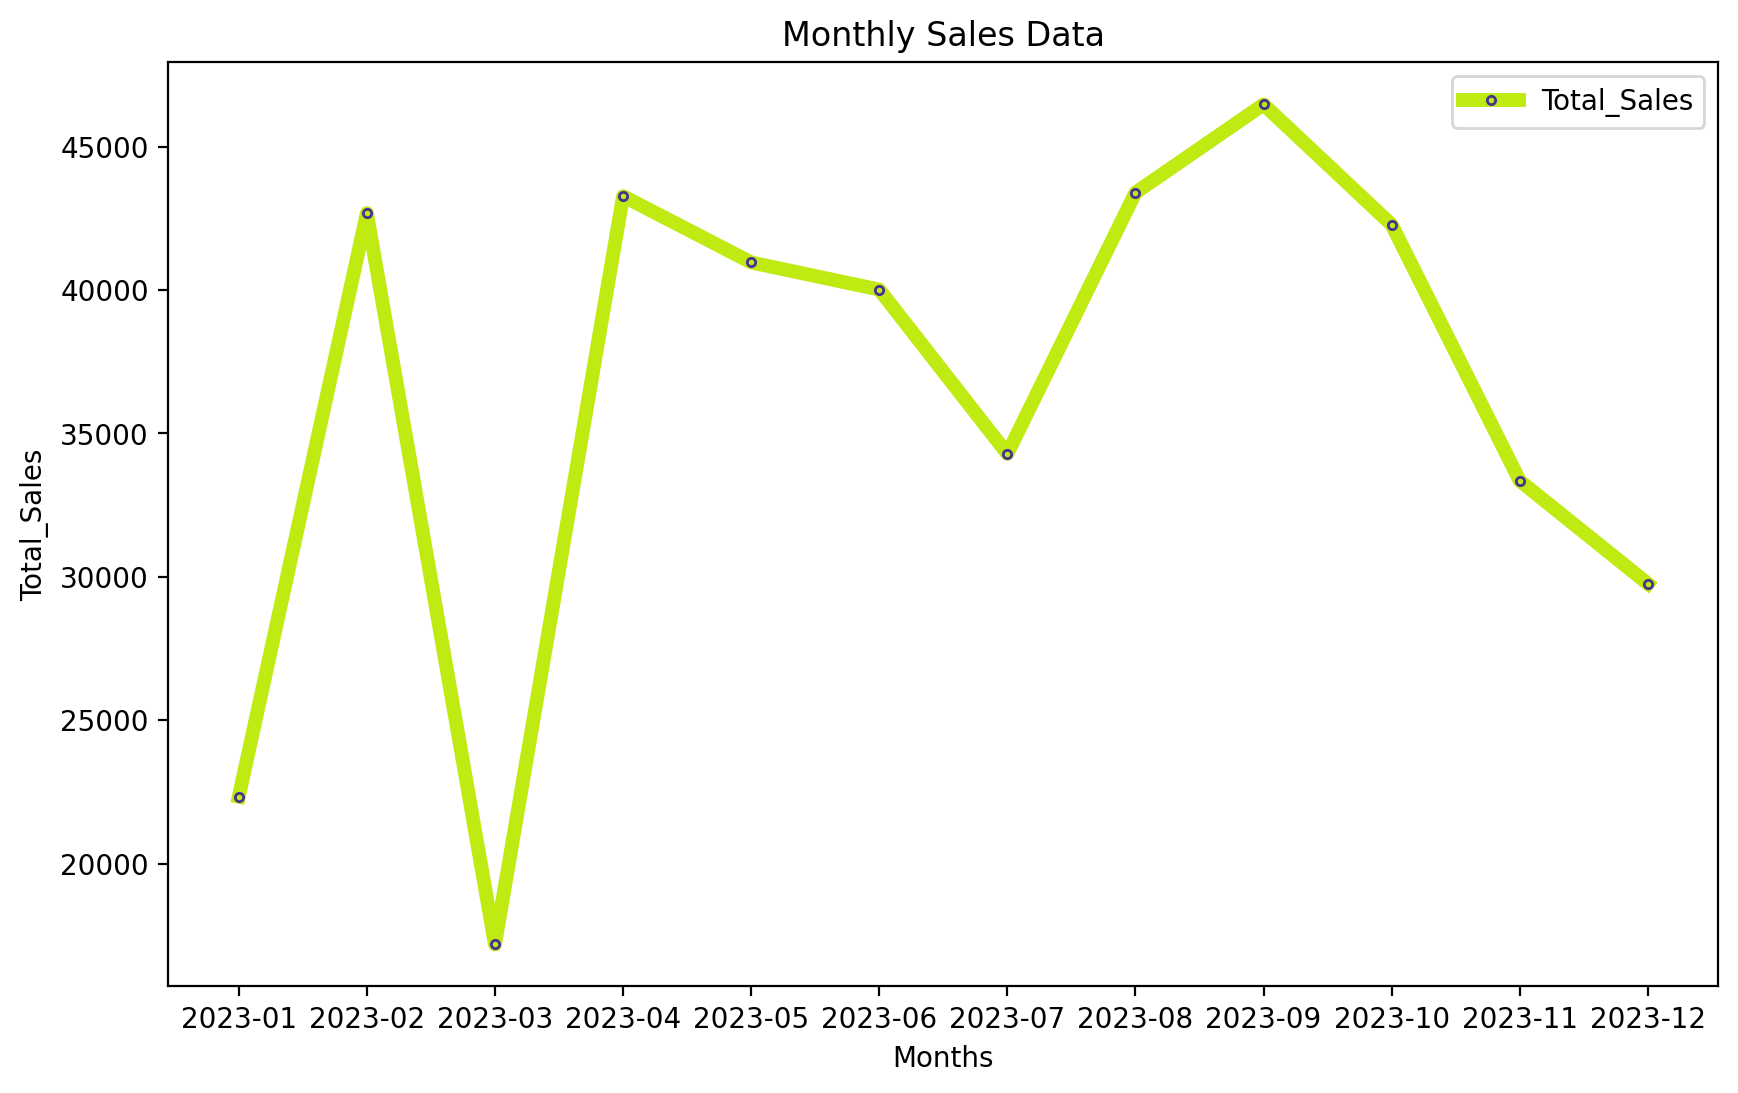

In [62]:
#Time series monthly wise sales in a line chart
monthly_wise_sales=df.groupby(df['Date'].dt.to_period('M'))['Total_Sales'].sum()

plt.figure(figsize=(10,6),dpi=200)
plt.title("Monthly Sales Data")
plt.xlabel("Months")
plt.ylabel("Total_Sales")
plt.plot(monthly_wise_sales.index.astype(str),monthly_wise_sales.values,linestyle="-",marker=".",color="#BFEA12",markeredgecolor="#483292",linewidth="5",label="Total_Sales")
plt.legend()
plt.savefig("Trends.png")
plt.show()




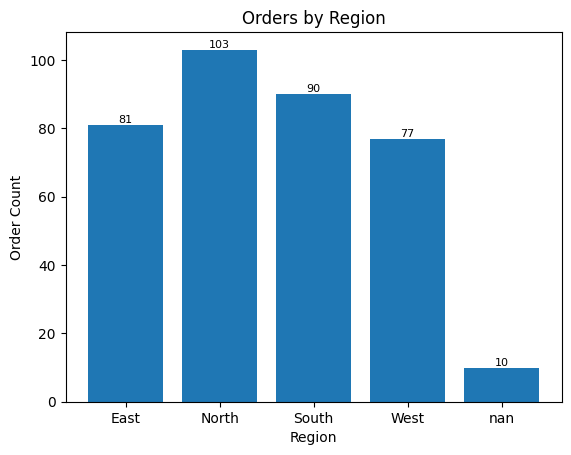

In [63]:
#Total Orders by Region
total_orders_region_wise=df.groupby("Region")["OrderID"].count()

plt.title("Orders by Region")
plt.xlabel("Region")
plt.ylabel("Order Count")
bars=plt.bar(total_orders_region_wise.index.astype(str),total_orders_region_wise.values)
for bar in bars:
    y=bar.get_height()
    x=bar.get_x()+bar.get_width()/2
    plt.text(x,y,str(y),va='bottom',ha='center',fontsize=8)

plt.show()


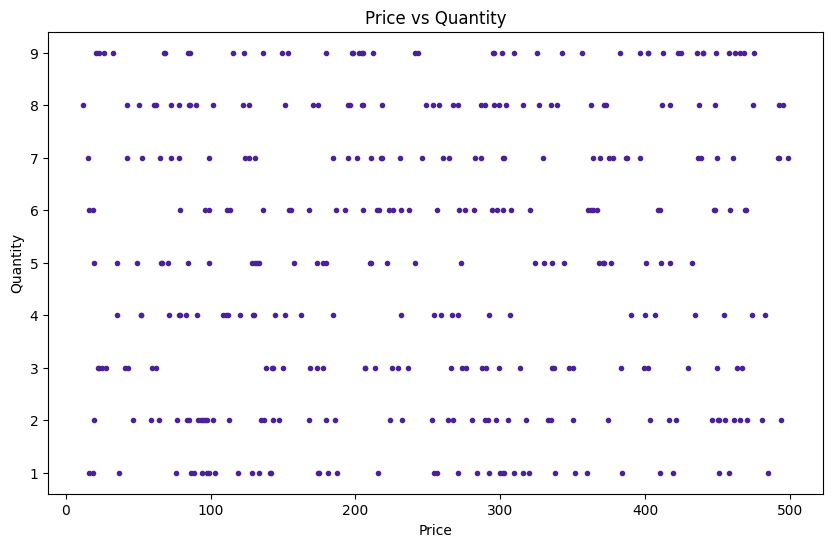

In [64]:
#Scatter Plot between Price and Quantity
plt.figure(figsize=(10,6))
plt.title("Price vs Quantity")
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.scatter(df["Price"],df["Quantity"],color="#4B2199",marker=".")
plt.show()

In [65]:
#Secondary dataset
returned_order_ids = np.random.choice(data['OrderID'], 20, replace=False)

returns_data = {
    'OrderID': returned_order_ids,
    'Return_Reason': np.random.choice(['Defective', 'Wrong Item', 'Changed Mind'], 20)
}

returns_df = pd.DataFrame(returns_data)

print("Returns Dataset Created!")
print(returns_df.head())


Returns Dataset Created!
   OrderID Return_Reason
0     1110  Changed Mind
1     1034    Wrong Item
2     1325    Wrong Item
3     1060  Changed Mind
4     1212  Changed Mind


Part IV:Data Merging and Relations

In [69]:
#Total Monetary loss
returned_orders=df[df["OrderID"].isin(returned_order_ids)]
total_loss=returned_orders["Total_Sales"].sum()
print(f"{total_loss:.2f}")


24135.07


In [78]:
#Left Join
order_details_df=pd.merge(df,returns_df,left_on="OrderID",right_on="OrderID",how="left")
order_details_df["Order_Status"]=order_details_df["Return_Reason"].apply(lambda x:"Completed" if pd.isna(x) else "Returned")
order_details_df.sample(10)

,OrderID,Date,Category,Region,Price,Quantity,Discount,Total_Sales,Return_Reason,Order_Status
40,1043,2023-11-03,Clothing,West,449.42,3,0.0,1348.260,NaN,Completed
326,1332,2023-08-08,Clothing,East,50.57,8,0.0,404.560,NaN,Completed
184,1188,2023-08-22,Books,North,299.72,1,0.0,299.720,NaN,Completed
295,1301,2023-10-04,Clothing,North,136.36,6,0.2,654.528,NaN,Completed
351,1357,2023-02-27,Clothing,South,252.79,2,0.0,505.580,NaN,Completed
149,1153,2023-06-09,Home,South,275.93,6,0.0,1655.580,NaN,Completed
126,1130,2023-08-06,Electronics,North,448.01,8,0.1,3225.672,NaN,Completed
91,1094,2023-10-28,Clothing,South,42.58,8,0.0,340.640,Wrong Item,Returned
323,1329,2023-02-18,Clothing,North,33.01,9,0.2,237.672,NaN,Completed
56,1059,2023-02-04,Home,East,147.19,2,0.0,294.380,NaN,Completed


Part V:Advanced Visualization


12.27
36.58
36.58
60.89
60.89
85.2
85.2
109.51
109.51
133.82000000000002
133.82000000000002
158.13000000000002
158.13000000000002
182.44000000000003
182.44000000000003
206.75000000000003
206.75000000000003
231.06000000000003
231.06000000000003
255.37000000000003
255.37000000000003
279.68
279.68
303.99
303.99
328.3
328.3
352.61
352.61
376.92
376.92
401.23
401.23
425.54
425.54
449.85
449.85
474.16
474.16
498.47


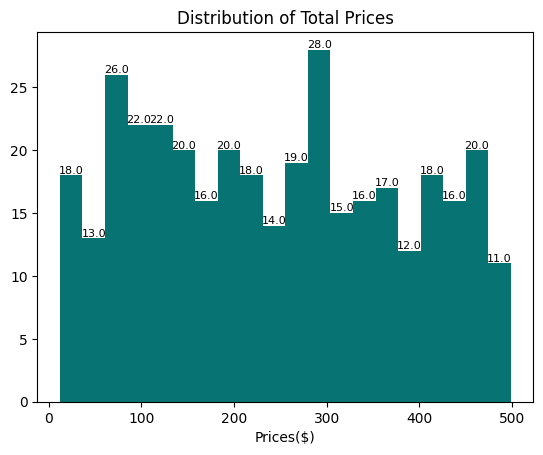

In [87]:
#Create a histogram with 20 bins with title Distribution of Product Prices
plt.title("Distribution of Total Prices")
plt.xlabel("Prices($)")
counts,bin_edges,patches=plt.hist(df["Price"],bins=20,label="Price",color="#077373")
for i in range(len(counts)):
    x=(bin_edges[i]+bin_edges[i+1])/2
    print(bin_edges[i])
    print(bin_edges[i+1])
    y=counts[i]
    plt.text(x,y,str(y),ha='center',va='bottom',fontsize="8")
plt.show()


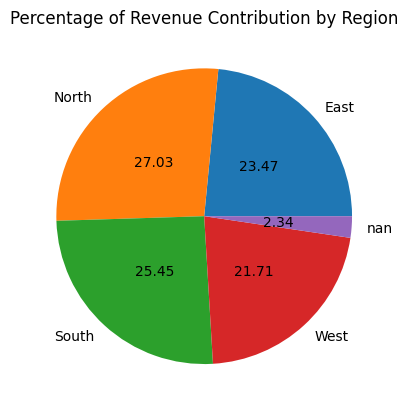

In [119]:
#Pie Chart
#Percentage revenue contribution per region

revenue_region_wise=df.groupby("Region")["Total_Sales"].sum()
x_values=revenue_region_wise.index.astype("str")
y_values=revenue_region_wise.values

plt.title("Percentage of Revenue Contribution by Region")
plt.pie(y_values,labels=x_values,autopct='%.2f',pctdistance=0.5)
plt.show()





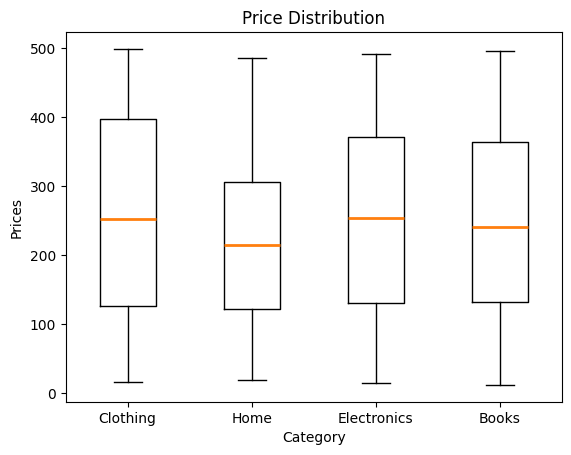

In [118]:
#Box plot
#Distribution of price across four different categories
categories=df["Category"].unique()
prices=[]

for category in categories:
    price=df[df["Category"]==category]["Price"]
    prices.append(price)

plt.title("Price Distribution")
plt.xlabel("Category")
plt.ylabel("Prices")
plt.boxplot(prices,tick_labels=categories,medianprops={"linewidth":2})
plt.show()
